In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import re
import collections
import torch.nn.functional as F
import math

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Text dataset

In [3]:
!wget -O fra-eng.zip http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip
!unzip -o fra-eng.zip -d .

--2026-03-28 16:44:17--  http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip
Resolving d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)... 3.163.164.229
Connecting to d2l-data.s3-accelerate.amazonaws.com (d2l-data.s3-accelerate.amazonaws.com)|3.163.164.229|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3420152 (3.3M) [application/zip]
Saving to: ‘fra-eng.zip’

fra-eng.zip         100%[===================>]   3.26M  --.-KB/s    in 0.05s   

2026-03-28 16:44:17 (60.3 MB/s) - ‘fra-eng.zip’ saved [3420152/3420152]

Archive:  fra-eng.zip
   creating: ./fra-eng/
  inflating: ./fra-eng/fra.txt       
  inflating: ./fra-eng/_about.txt    


In [4]:
def read_data():
    with open("fra-eng/fra.txt", 'r') as f:
        return f.read()

In [5]:
raw_text = read_data()
print(raw_text[:75])

Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !



In [6]:
def process_text(text):
    text = text.replace('\u202f', ' ').replace('\xa0', ' ')
    no_space = lambda char, prev_char: char in ',.!?' and prev_char != ' '
    out = [' ' + char if i>0 and no_space(char, text[i-1]) else char for i,char in enumerate(text.lower())]
    return ''.join(out)

In [7]:
processed_text = process_text(raw_text)
print(processed_text[:75])

go .	va !
hi .	salut !
run !	cours !
run !	courez !
who ?	qui ?
wow !	ça al


In [8]:
def tokenize(text, max_examples=None):
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if max_examples and i>max_examples: break
        parts = line.split('\t')
        if len(parts)==2:
            source.append([t for t in f'{parts[0]} <eos>'.split(' ') if t])
            target.append([t for t in f'{parts[1]} <eos>'.split(' ') if t])
    return source, target

In [9]:
source, target = tokenize(processed_text)
source[:5], target[:5]

([['go', '.', '<eos>'],
  ['hi', '.', '<eos>'],
  ['run', '!', '<eos>'],
  ['run', '!', '<eos>'],
  ['who', '?', '<eos>']],
 [['va', '!', '<eos>'],
  ['salut', '!', '<eos>'],
  ['cours', '!', '<eos>'],
  ['courez', '!', '<eos>'],
  ['qui', '?', '<eos>']])

In [10]:
class Vocab:
    def __init__(self, tokens, min_freq=0, reserved_tokens=[]):
        if tokens and isinstance(tokens[0], list):
            tokens = [t for line in tokens for t in line]
        counter = collections.Counter(tokens)
        self.freq_count = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_tokens = list(sorted(set(["<unk>"] + reserved_tokens + [t for t,f in self.freq_count if f>=min_freq])))
        self.tokens_to_idx = {t:i for i,t in enumerate(self.idx_to_tokens)}

    def __len__(self): return len(self.idx_to_tokens)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.tokens_to_idx.get(tokens, self.unk)
        return [self.__getitem__(t) for t in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, "__len__") and len(indices) > 1:
            return [self.idx_to_tokens[i] for i in indices]
        return self.idx_to_tokens[indices]

    @property
    def unk(self): return self.tokens_to_idx["<unk>"]

In [11]:
def build_arrays(raw_text, num_steps=9, src_vocab=None, tgt_vocab=None, num_train=None, num_eval=None):
    def build_array(sentences, vocab, is_tgt=False):
        pad_or_trim = lambda seq, n_steps: (
            seq[:n_steps] if n_steps<len(seq) else seq + ['<pad>'] * (n_steps-len(seq))
        )
        sentences = [pad_or_trim(s, num_steps) for s in sentences]
        if is_tgt:
          sentences = [["<sos>"] + s for s in sentences]
        if vocab is None:
          vocab = Vocab(sentences, min_freq=2, reserved_tokens=["<pad>", "<eos>", "<sos>"])
        array = torch.tensor([vocab[s] for s in sentences])
        valid_len = (array != vocab["<pad>"]).type(torch.int64).sum(dim=1)
        return array, vocab, valid_len
    max_examples = num_train+num_eval if (num_train is not None and num_eval is not None) else None
    src, tgt = tokenize(process_text(raw_text), max_examples)
    src_array, src_vocab, src_valid_len = build_array(src, src_vocab)
    tgt_array, tgt_vocab, _ = build_array(tgt, tgt_vocab, True)
    return (
        (src_array, tgt_array[:, :-1], src_valid_len, # model input
        tgt_array[:, 1:]), # model labels
        src_vocab, tgt_vocab
    )

In [12]:
num_train = 512
num_eval = 128
num_steps = 9
arrays, src_vocab, tgt_vocab = build_arrays(raw_text=read_data(),num_steps=num_steps,
                                            num_train=num_train, num_eval=num_eval)

In [13]:
(arrays[0][0],
 src_vocab.to_tokens(arrays[0][0]),
 tgt_vocab.to_tokens(arrays[1][0]),
 arrays[2][0],
 tgt_vocab.to_tokens(arrays[3][0]))

(tensor([60,  2,  3,  4,  4,  4,  4,  4,  4]),
 ['go', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'],
 ['<sos>', 'va', '!', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'],
 tensor(3),
 ['va', '!', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'])

In [14]:
def get_dataloader(arrays, shuffle, batch_size):
    indices = slice(0, num_train) if shuffle else slice(num_train, num_train+num_eval)
    dataset = torch.utils.data.TensorDataset(*[a[indices] for a in arrays])
    return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_dataloader = get_dataloader(arrays, True, 4)
eval_dataloader = get_dataloader(arrays, False, 4)

In [15]:
src, tgt, src_valid_len, label = next(iter(train_dataloader))
print("source ids:", src)
print("source tokens:", [src_vocab.to_tokens(s) for s in src])
print("target ids:", tgt)
print("target tokens", [tgt_vocab.to_tokens(t) for t in tgt])
print("src_valid_len:", src_valid_len)
print("label ids:", label)
print("label tokens:", [tgt_vocab.to_tokens(t) for t in label])

source ids: tensor([[ 86, 173,   2,   3,   4,   4,   4,   4,   4],
        [ 87,  77,   2,   3,   4,   4,   4,   4,   4],
        [ 17, 141,   2,   3,   4,   4,   4,   4,   4],
        [184, 191,   2,   3,   4,   4,   4,   4,   4]])
source tokens: [["i'll", 'try', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'], ["i'm", 'home', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'], ['be', 'seated', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>'], ['we', 'won', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']]
target ids: tensor([[  5, 108, 202,   6,   2,   3,   4,   4,   4],
        [  5, 108, 183,  47, 129,   2,   3,   4,   4],
        [  5,  19,   0,   3,   4,   4,   4,   4,   4],
        [  5, 135,   6,   2,   3,   4,   4,   4,   4]])
target tokens [['<sos>', 'je', 'vais', '<unk>', '.', '<eos>', '<pad>', '<pad>', '<pad>'], ['<sos>', 'je', 'suis', 'chez', 'moi', '.', '<eos>', '<pad>', '<pad>'], ['<sos>', 'assieds-toi', '!', '<eos>', '<pad>', '<pad

# Model

In [16]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()

    def forward(self, x, *args):
        raise NotImplemented

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()

    def init_state(self, enc_all_outputs, *args):
        raise NotImplemented

    def forward(self, x, state):
        raise NotImplemented

class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_x, dec_x, *args):
        enc_all_outputs = self.encoder(enc_x, *args)
        dec_state = self.decoder.init_state(enc_all_outputs)
        dec_outputs = self.decoder(dec_x, dec_state)
        return dec_outputs


In [17]:
def init_seq2seq(module):
    if type(module) == nn.Linear:
        nn.init.xavier_uniform_(module.weight)
    if type(module) == nn.GRU:
        for param in module._flat_weights_names:
            if "weight" in param:
                nn.init.xavier_uniform_(module._parameters[param])

In [18]:
class Seq2SeqEncoder(Encoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super(Seq2SeqEncoder, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_size)
        self.rnn = nn.GRU(input_size=embed_size, hidden_size=num_hiddens, num_layers=num_layers, dropout=dropout)
        self.apply(init_seq2seq)

    def forward(self, x, *args):
        # x shape: (batch_size, num_steps)
        embs = self.embedding(x.t().type(torch.int64))
        # embs shape: (num_steps, batch_size, embed_size)
        outputs, state = self.rnn(embs)
        # outputs shape: (num_steps, batch_size, num_hiddens)
        # state shape: (num_layers, batch_size, num_hiddens)
        return outputs, state

In [19]:
vocab_size = 10
embed_size = 8
num_hiddens = 16
num_layers = 2
batch_size = 4
num_steps = 9
encoder = Seq2SeqEncoder(vocab_size=vocab_size, embed_size=embed_size,
                         num_hiddens=num_hiddens, num_layers=num_layers)
x = torch.zeros((batch_size, num_steps))
enc_out, enc_state = encoder(x)
x.shape, enc_out.shape, enc_state.shape


(torch.Size([4, 9]), torch.Size([9, 4, 16]), torch.Size([2, 4, 16]))

In [20]:
class Seq2SeqDecoder(Decoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super(Seq2SeqDecoder, self).__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_size)
        self.rnn = nn.GRU(input_size=embed_size+num_hiddens, hidden_size=num_hiddens, num_layers=num_layers, dropout=dropout)
        self.dense = nn.Linear(in_features=num_hiddens, out_features=vocab_size)
        self.apply(init_seq2seq)

    def init_state(self, enc_all_outputs, *args):
        return enc_all_outputs


    def forward(self, x, state):
        # x shape: (batch_size, num_steps)
        embs = self.embedding(x.t().type(torch.int64))
        # embs shape: (num_steps, batch_size, embed_size)
        enc_output, hidden_state = state
        # context shape: (num_steps, batch_size, num_hiddens)
        context = enc_output[-1]
        # context shape: (batch_size, num_hiddens)
        context = context.repeat(embs.shape[0], 1, 1)
        # context shape: (num_steps, batch_size, num_hiddens)
        embs_and_context = torch.cat((embs, context), dim=-1)
        # embs_and_context shape: (num_steps, batch_size, num_hiddens+embed_size)
        outputs, hidden_state = self.rnn(embs_and_context, hidden_state)
        # outputs shape: (num_steps, batch_size, num_hiddens)
        outputs = self.dense(outputs).swapaxes(0, 1)
        # outputs shape: (batch_size, num_steps, vocab_size)
        return outputs, [enc_output, hidden_state]

In [21]:
decoder = Seq2SeqDecoder(vocab_size=vocab_size, embed_size=embed_size,
                         num_hiddens=num_hiddens, num_layers=num_layers)
state = decoder.init_state(encoder(x))
dec_outputs, state = decoder(x, state)
dec_outputs.shape, state[0].shape, state[1].shape

(torch.Size([4, 9, 10]), torch.Size([9, 4, 16]), torch.Size([2, 4, 16]))

In [22]:
class Seq2Seq(EncoderDecoder):
    def __init__(self, encoder, decoder, tgt_pad):
        super(Seq2Seq, self).__init__(encoder, decoder)
        self.tgt_pad = tgt_pad


In [23]:
def grad_clip(clip_val, model):
    params = [p for p in model.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum((p.grad**2)) for p in params))
    if norm > clip_val:
        for p in params:
            p.grad[:] *= clip_val / norm

In [24]:
def train_deep_encoder_decoder(model, max_epochs, clip_val, lr, train_dataloader, eval_dataloader, report_every):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    metrics = {"train_loss": [], "train_acc": [], "eval_loss": [], "eval_acc": []}
    criterion = nn.CrossEntropyLoss(reduction="none")

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr)

    for epoch in range(max_epochs):
        model.train()
        num_instances = 0
        epoch_loss = 0.
        epoch_acc = 0.
        for step, batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            logits, _ = model(*batch[:-1])
            logits = logits.reshape(-1, logits.shape[-1])
            labels = batch[-1].reshape(-1,)
            loss = criterion(logits, labels)
            mask = (labels != model.tgt_pad).type(torch.float32)
            loss = (loss*mask).sum() / mask.sum()
            loss.backward()
            grad_clip(clip_val, model)
            optimizer.step()
            epoch_loss += loss.item() * bs
            epoch_acc += (torch.softmax(logits, dim=-1).argmax(dim=-1)==labels).type(torch.float32).mean().item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_acc /= num_instances
        metrics["train_loss"].append(epoch_loss)
        metrics["train_acc"].append(epoch_acc)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] train_loss: {epoch_loss:.5f}, train_acc: {epoch_acc:.5f}")

        model.eval()
        num_instances = 0
        epoch_loss = 0.
        epoch_acc = 0.
        for step, batch in enumerate(eval_dataloader):
            batch = [a.to(device) for a in batch]
            bs = batch[-1].size(0)
            with torch.no_grad():
                logits, _ = model(*batch[:-1])
                logits = logits.reshape(-1, logits.shape[-1])
                labels = batch[-1].reshape(-1,)
                loss = criterion(logits, labels)
                mask = (labels != model.tgt_pad).type(torch.float32)
                loss *= mask
                loss = (loss*mask).sum() / mask.sum()
                epoch_loss += loss.item() * bs
                epoch_acc += (torch.softmax(logits, dim=-1).argmax(dim=-1)==labels).type(torch.float32).mean().item() * bs
            num_instances += bs

        epoch_loss /= num_instances
        epoch_acc /= num_instances
        metrics["eval_loss"].append(epoch_loss)
        metrics["eval_acc"].append(epoch_acc)
        if epoch % report_every==0:
            print(f"[{epoch}/{max_epochs}] eval_loss: {epoch_loss:.5f}, eval_acc: {epoch_acc:.5f}")

    return metrics


In [25]:
embed_size = 256
num_hiddens = 256
num_layers = 2
dropout = 0.2
encoder = Seq2SeqEncoder(vocab_size=len(src_vocab), embed_size=embed_size, num_hiddens=num_hiddens, num_layers=num_layers, dropout=dropout)
decoder = Seq2SeqDecoder(vocab_size=len(tgt_vocab), embed_size=embed_size, num_hiddens=num_hiddens, num_layers=num_layers, dropout=dropout)
model = Seq2Seq(encoder=encoder, decoder=decoder, tgt_pad=tgt_vocab["<pad>"])

lr = 0.005
max_epochs = 30
clip_val = 1
metrics = train_deep_encoder_decoder(model=model, max_epochs=max_epochs, clip_val=clip_val, lr=lr,
                                     train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, report_every=10)


[0/30] train_loss: 2.58501, train_acc: 0.24566
[0/30] eval_loss: 3.35585, eval_acc: 0.26389
[10/30] train_loss: 1.01449, train_acc: 0.35482
[10/30] eval_loss: 3.88364, eval_acc: 0.27344
[20/30] train_loss: 0.82402, train_acc: 0.36979
[20/30] eval_loss: 4.83298, eval_acc: 0.26215


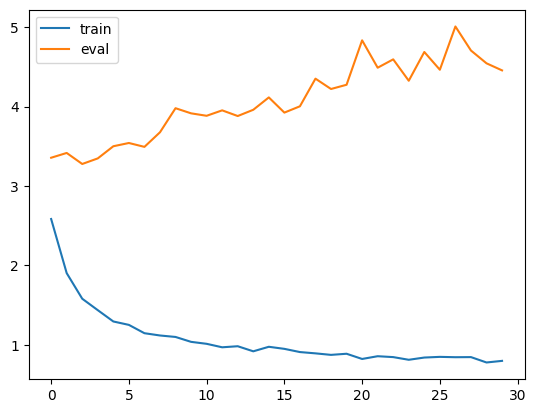

In [26]:
plt.plot(metrics["train_loss"], label="train")
plt.plot(metrics["eval_loss"], label="eval")
plt.legend(); plt.show()

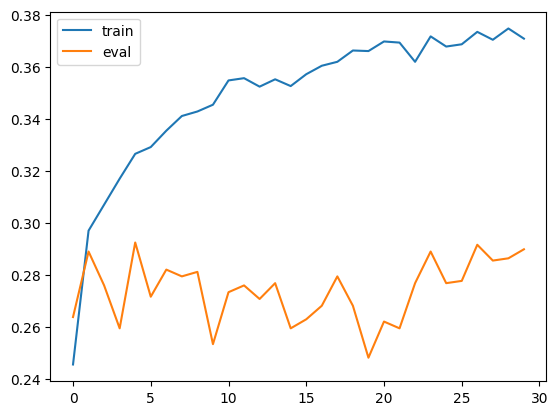

In [27]:
plt.plot(metrics["train_acc"], label="train")
plt.plot(metrics["eval_acc"], label="eval")
plt.legend(); plt.show()

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def greedy_search(batch, model, device, num_steps):
    batch = [a.to(device) for a in batch]
    src, tgt, src_valid_len, _ = batch
    enc_all_outputs = model.encoder(src, src_valid_len)
    dec_state = model.decoder.init_state(enc_all_outputs, src_valid_len)
    outputs = [tgt[:, (0)].unsqueeze(1), ]
    for _ in range(num_steps):
        out, dec_state = model.decoder(outputs[-1], dec_state)
        outputs.append(out.argmax(dim=2))
    return torch.cat(outputs[1:], 1).detach().cpu().numpy()


In [29]:
def bleu_score(pred_seq, true_seq, k):
    pred_tokens, true_tokens = map(lambda x: x.split(' '), (pred_seq, true_seq))
    len_pred = len(pred_tokens)
    len_true = len(true_tokens)
    score = math.exp(min(0, 1-len_true/len_pred))
    for n in range(1, min(k, len_pred)+1):
        num_matches = 0
        label_subs = collections.defaultdict(int)
        for i in range(len_true - n + 1):
            label_subs[' '.join(true_tokens[i:i+n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i:i+n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i:i+n])] -= 1
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    return score

In [30]:
eng_sentences = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fra_sentences = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
raw_text = '\n'.join([src + '\t' + tgt for src, tgt in zip(eng_sentences, fra_sentences)])
test_arrays, _, _ = build_arrays(raw_text, src_vocab=src_vocab, tgt_vocab=tgt_vocab)

In [31]:
preds = greedy_search(test_arrays, model, device, 15)
for en, fr, p in zip(eng_sentences, fra_sentences, preds):
    translation = []
    for token in tgt_vocab.to_tokens(p):
        if token=="<eos>":
            break
        translation.append(token)
    translation = ' '.join(translation)
    bleu = bleu_score(translation, fr, k=2)
    print(f"english= {en.ljust(15)} -- translated to={translation.ljust(30)} -- label={fr.ljust(20)} -- bleu_score: {bleu:.5f}")

english= go .            -- translated to=va te faire faire foutre !     -- label=va !                 -- bleu_score: 0.00000
english= i lost .        -- translated to=j'ai perdu .                   -- label=j'ai perdu .         -- bleu_score: 1.00000
english= he's calm .     -- translated to=il est calme .                 -- label=il est calme .       -- bleu_score: 1.00000
english= i'm home .      -- translated to=je chez moi .                  -- label=je suis chez moi .   -- bleu_score: 0.70373


In [143]:
def beam_search(beam_size, batch, model, device, num_steps):
    batch = [a.to(device) for a in batch]
    src, tgt, src_valid_len, _ = batch

    # for i in range(len(src)):
    for i in range(1):

      enc_all_outputs = model.encoder(src[i, None, :].repeat(beam_size, 1), src_valid_len[i, None].repeat(beam_size, 1))
      dec_state = model.decoder.init_state(enc_all_outputs, src_valid_len)
      outputs = [tgt[i, 0, None].repeat(beam_size, 1)]

      # enc_all_outputs = model.encoder(src[i, None, :], src_valid_len[i, None])
      # dec_state = model.decoder.init_state(enc_all_outputs, src_valid_len)

      log_probs = torch.zeros((beam_size,1))

      for _ in range(num_steps):
          print("outputs[-1].shape:", outputs[-1].shape)
          out, dec_state = model.decoder(outputs[-1], dec_state)
          # probs = torch.log(torch.softmax(out, dim=-1))
          probs = F.log_softmax(out, dim=-1)
          vocab_size = probs.shape[-1]
          # print("outputs.shape:", outputs.shape)
          print("probs.shape:", probs.shape)
          print("log_probs.shape:", log_probs.shape)
          combined = (log_probs + probs).flatten()
          print("combined.shape:", combined.shape)
          top_probs, top_indices = combined.topk(beam_size)


          print("top_indices.shape:", top_indices.shape)
          print("top_probs.shape:", top_probs.shape)

          print("top_probs:", top_probs)
          print("top_indices:", top_indices)
          print("top_indices % vocab_size:", top_indices % vocab_size)

          log_probs = top_probs.reshape(-1,1)
          top_indices %= vocab_size
          parent_beams = top_indices // vocab_size

          print("top_indices:", top_indices)
          print("parent_beams:", parent_beams)
          outputs.append(top_indices)


          print("="*20)
      # return outputs[:, 1:].detach().cpu().numpy()
# preds = beam_search(3, arrays, model, device, 4)
beam_search(2, test_arrays, model, device, 4)


outputs[-1].shape: torch.Size([2, 1])
probs.shape: torch.Size([2, 1, 214])
log_probs.shape: torch.Size([2, 1])
combined.shape: torch.Size([856])
top_indices.shape: torch.Size([2])
top_probs.shape: torch.Size([2])
top_probs: tensor([-0.6481, -0.6481], grad_fn=<TopkBackward0>)
top_indices: tensor([415, 201])
top_indices % vocab_size: tensor([201, 201])
top_indices: tensor([201, 201])
parent_beams: tensor([0, 0])
outputs[-1].shape: torch.Size([2])


RuntimeError: Tensors must have same number of dimensions: got 2 and 3

In [114]:
tgt_vocab.to_tokens(201)

'va'